<div style="background:linear-gradient(135deg,#512E5F 0%,#7D3C98 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#D7BDE2;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 4 · CLASE 11</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">PCA — Cuántos Componentes Retener</h1>
  <p style="color:#D7BDE2;font-size:16px;margin:0 0 24px 0;font-style:italic;">Kaiser · Codo · Loadings · Reconstrucción · Pipeline PCA + clasificación</p>
  <hr style="border-color:#A569BD;margin:0 0 20px 0;">
  <p style="color:#F5EEF8;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Módulo 4:</strong> PCA &nbsp;·&nbsp; 2 horas</p>
</div>

## Objetivos
| # | Al terminar podés |
|---|-------------------|
| 1 | Aplicar 3 criterios de selección: varianza acumulada, codo y Kaiser |
| 2 | Leer e interpretar la matriz de loadings |
| 3 | Medir el error de reconstrucción en función de k |
| 4 | Construir un pipeline PCA + clasificación supervisada |
| 5 | Nombrar las PCs usando los loadings más altos |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
SEED=42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 1. Tres criterios para elegir k

| Criterio | Regla | Cuándo usar |
|----------|-------|-------------|
| **% varianza** | Retener k hasta cubrir 80%–95% | Siempre — punto de partida |
| **Codo** | k donde la curva del scree plot 'dobla' | Cuando hay señal clara |
| **Kaiser** | Retener PCs con λ > 1 (sobre datos estandarizados) | Datos estandarizados |

In [2]:
np.random.seed(SEED)
n_k, p_k = 400, 12
# Dataset: señal real en 4 dimensiones
X_raw=np.random.randn(n_k, 4) @ np.random.randn(4, p_k) + np.random.randn(n_k, p_k) * 0.3
X_raw_sc=StandardScaler().fit_transform(X_raw)

pca_k=PCA(); pca_k.fit(X_raw_sc)
ev_ratio=pca_k.explained_variance_ratio_
ev_cum  =np.cumsum(ev_ratio)
ev_vals =pca_k.explained_variance_

# Criterio 1: % varianza
k_80=np.argmax(ev_cum>=0.80)+1; k_95=np.argmax(ev_cum>=0.95)+1

# Criterio 2: Kaiser
k_kaiser=int(np.sum(ev_vals>1))

# Criterio 3: codo — segunda diferencia del scree
diffs2=np.diff(np.diff(ev_ratio))
k_codo=int(np.argmax(np.abs(diffs2))+2)

print('═'*50)
print('  Criterios de selección de k')
print('═'*50)
print(f'  80% varianza:    k = {k_80}')
print(f'  95% varianza:    k = {k_95}')
print(f'  Kaiser (λ>1):    k = {k_kaiser}')
print(f'  Codo (Δ²):       k ≈ {k_codo}')
print(f'  Señal real:      k = 4  ← ground truth')
print('═'*50)

══════════════════════════════════════════════════
  Criterios de selección de k
══════════════════════════════════════════════════
  80% varianza:    k = 3
  95% varianza:    k = 4
  Kaiser (λ>1):    k = 4
  Codo (Δ²):       k ≈ 5
  Señal real:      k = 4  ← ground truth
══════════════════════════════════════════════════


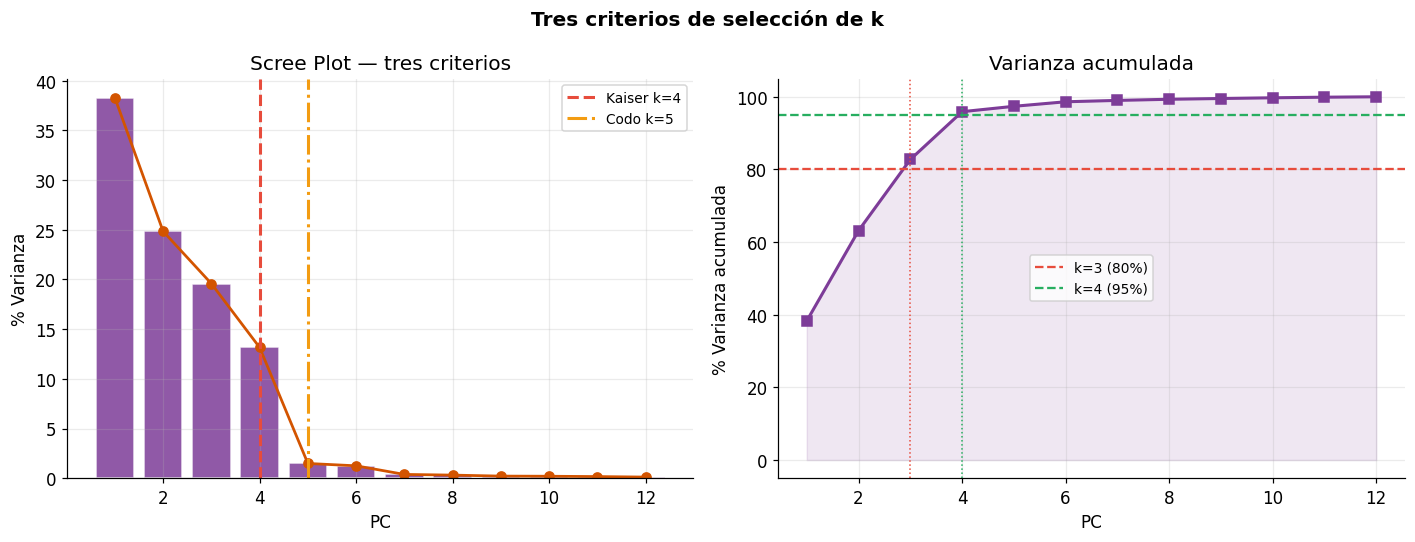

→ Los tres criterios apuntan a k≈4, que coincide con la señal real.


In [3]:
# Visualización comparativa
fig, axes=plt.subplots(1,2,figsize=(13,5))
ks=range(1,p_k+1)

axes[0].bar(ks, ev_ratio*100, color='#7D3C98', alpha=0.85, edgecolor='white')
axes[0].plot(ks, ev_ratio*100, 'o-', color='#D35400', lw=1.8, markersize=6)
axes[0].axvline(k_kaiser, color='#E74C3C', lw=2, linestyle='--', label=f'Kaiser k={k_kaiser}')
axes[0].axvline(k_codo,   color='#F39C12', lw=2, linestyle='-.', label=f'Codo k={k_codo}')
axes[0].set(xlabel='PC', ylabel='% Varianza', title='Scree Plot — tres criterios')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

axes[1].plot(ks, ev_cum*100, 's-', color='#7D3C98', lw=2)
axes[1].fill_between(ks, ev_cum*100, alpha=0.12, color='#7D3C98')
for k_,pct_,col_ in [(k_80,80,'#E74C3C'),(k_95,95,'#27AE60')]:
    axes[1].axhline(pct_, color=col_, lw=1.5, linestyle='--', label=f'k={k_} ({pct_}%)')
    axes[1].axvline(k_, color=col_, lw=1, linestyle=':')
axes[1].set(xlabel='PC', ylabel='% Varianza acumulada', title='Varianza acumulada')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.25)

plt.suptitle('Tres criterios de selección de k', fontweight='bold')
plt.tight_layout(); plt.show()
print('→ Los tres criterios apuntan a k≈4, que coincide con la señal real.')

---
## 2. Loadings — qué combinación de features es cada PC

**Loading = correlación de cada feature original con cada PC.**

- Loading grande (en valor absoluto) → esa feature tiene mucho peso en la PC
- Loadings similares → features que 'se mueven juntas'

In [4]:
np.random.seed(SEED)
feats_l=['ingresos','edad','deuda','productos','historial','educacion']
n_l=300
Sigma_l=np.diag([4,2,3,1,2,1])+0.5*np.ones((6,6))
X_l=np.random.multivariate_normal(np.zeros(6), Sigma_l, n_l)

pca_l=PCA(n_components=3); pca_l.fit(StandardScaler().fit_transform(X_l))

loadings_df=pd.DataFrame(pca_l.components_.T,
    index=feats_l, columns=['PC1','PC2','PC3'])

print('Matriz de loadings (cada fila = feature, cada col = PC):')
print(loadings_df.round(3).to_string())

print(f'\nVarianza explicada: {pca_l.explained_variance_ratio_.round(3)}')
print(f'Varianza acumulada: {pca_l.explained_variance_ratio_.cumsum().round(3)}')

print('\nFeatures con mayor loading en cada PC:')
for pc in ['PC1','PC2','PC3']:
    top=loadings_df[pc].abs().nlargest(2)
    print(f'  {pc}: {list(top.index)} (loadings: {top.values.round(3)})')

Matriz de loadings (cada fila = feature, cada col = PC):
             PC1    PC2    PC3
ingresos   0.147  0.771 -0.479
edad       0.444  0.011  0.263
deuda      0.385 -0.492 -0.409
productos  0.481  0.107 -0.338
historial  0.357  0.340  0.642
educacion  0.523 -0.194  0.086

Varianza explicada: [0.31  0.18  0.151]
Varianza acumulada: [0.31  0.49  0.641]

Features con mayor loading en cada PC:
  PC1: ['educacion', 'productos'] (loadings: [0.523 0.481])
  PC2: ['ingresos', 'deuda'] (loadings: [0.771 0.492])
  PC3: ['historial', 'ingresos'] (loadings: [0.642 0.479])


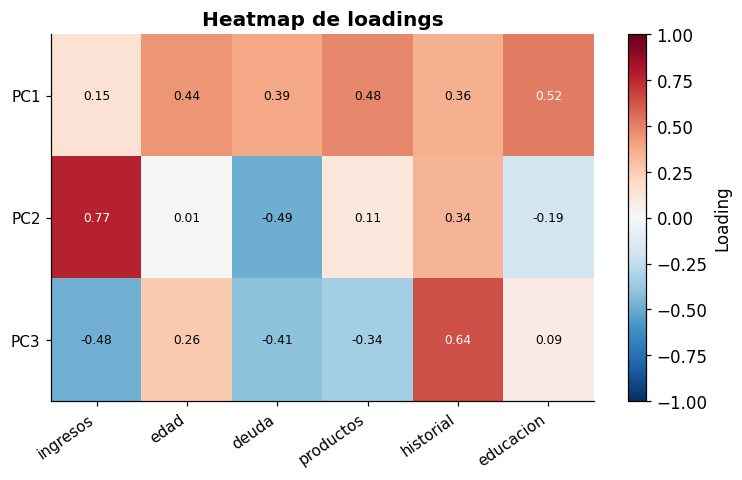

Rojo = loading positivo alto | Azul = loading negativo alto | Blanco ≈ 0


In [5]:
# Heatmap de loadings
fig, ax=plt.subplots(figsize=(7, 4.5))
im=ax.imshow(loadings_df.values.T, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Loading')
ax.set_xticks(range(len(feats_l)))
ax.set_xticklabels(feats_l, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(3))
ax.set_yticklabels(['PC1','PC2','PC3'], fontsize=10)
for i in range(3):
    for j in range(len(feats_l)):
        val=loadings_df.values[j,i]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val)>0.5 else 'black')
ax.set_title('Heatmap de loadings', fontweight='bold')
plt.tight_layout(); plt.show()
print('Rojo = loading positivo alto | Azul = loading negativo alto | Blanco ≈ 0')

---
## 3. Error de reconstrucción vs k

Con k < p PCs, al reconstruir X perdemos información. El **error de reconstrucción** mide cuánta se pierde.

$$\text{MSE}(k) = \frac{1}{np} \|X - \hat{X}_k\|_F^2$$

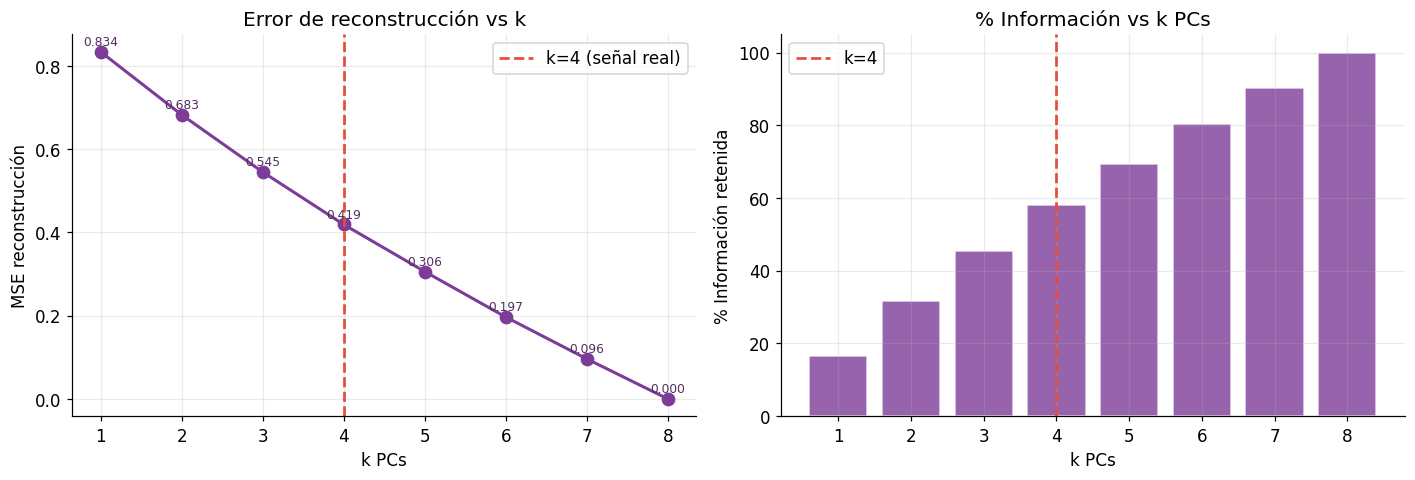

k  Error    % info retenida
 1  0.8342   16.6%
 2  0.6828   31.7%
 3  0.5453   45.5%
 4  0.4191   58.1%
 5  0.3060   69.4%
 6  0.1967   80.3%
 7  0.0961   90.4%
 8  0.0000   100.0%


In [6]:
np.random.seed(SEED)
n_r, p_r = 200, 8
# Señal fuerte en primeras 4 dims — el resto es ruido
X_rec=np.random.randn(n_r, p_r) @ np.diag([3.0, 2.5, 2.0, 1.5, 0.5, 0.3, 0.2, 0.1])
X_rec_sc=StandardScaler().fit_transform(X_rec)

# Calcular MSE para cada k
pca_all=PCA(); pca_all.fit(X_rec_sc)
var_all=np.cumsum(pca_all.explained_variance_ratio_)

errores=[]
for k in range(1, p_r+1):
    pca_r=PCA(n_components=k)
    Xr=pca_r.fit_transform(X_rec_sc)
    Xrec=pca_r.inverse_transform(Xr)
    errores.append(np.mean((X_rec_sc - Xrec)**2))

fig, axes=plt.subplots(1, 2, figsize=(13, 4.5))
ks_r=range(1, p_r+1)

axes[0].plot(ks_r, errores, 'o-', color='#7D3C98', lw=2, markersize=8)
axes[0].axvline(4, color='#E74C3C', lw=1.8, linestyle='--', label='k=4 (señal real)')
for k,e in enumerate(errores, 1):
    axes[0].annotate(f'{e:.3f}', (k, e+0.015), ha='center', fontsize=8, color='#512E5F')
axes[0].set(xlabel='k PCs', ylabel='MSE reconstrucción',
           title='Error de reconstrucción vs k')
axes[0].legend(); axes[0].grid(True, alpha=0.25)

axes[1].bar(ks_r, (1-np.array(errores))*100, color='#7D3C98', alpha=0.8, edgecolor='white')
axes[1].axvline(4, color='#E74C3C', lw=1.8, linestyle='--', label='k=4')
axes[1].set(xlabel='k PCs', ylabel='% Información retenida',
           title='% Información vs k PCs')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.tight_layout(); plt.show()

print('k  Error    % info retenida')
for k,e in enumerate(errores, 1):
    print(f'{k:2d}  {e:.4f}   {(1-e)*100:.1f}%')

---
## 4. Pipeline PCA + Clasificación supervisada

PCA como preprocesamiento: reduce dimensionalidad → el clasificador trabaja con menos features (menos ruido).

In [7]:
np.random.seed(SEED)
n_pp, p_full = 600, 20
# Señal en 6 dimensiones latentes
Z=np.random.randn(n_pp, 6)
X_full=Z @ np.random.randn(6, p_full) + np.random.randn(n_pp, p_full) * 0.5
y_full=np.random.binomial(1, 1/(1+np.exp(-(Z@np.array([1.5,-1.2,0.8,-0.6,1.0,-0.5])-0.3))))

Xtr_f,Xte_f,ytr_f,yte_f=train_test_split(X_full, y_full, test_size=0.25, random_state=SEED)

print(f'Dataset: {n_pp} obs · {p_full} features · señal real en 6 dims')
print(f'Tasa positivos: {y_full.mean():.1%}\n')
print(f'{"Pipeline":30s} {"Var%":>7s} {"Accuracy":>10s}')
print('─'*52)

# Baseline: sin PCA
sc_base=StandardScaler()
lr_base=LogisticRegression(C=1e6, solver='lbfgs', max_iter=500)
lr_base.fit(sc_base.fit_transform(Xtr_f), ytr_f)
acc_base=accuracy_score(yte_f, lr_base.predict(sc_base.transform(Xte_f)))
print(f'  Logística (20 features) {"":5s} {"100%":>7s} {acc_base:>10.4f}')

# Con PCA para distintos k
for k in [4, 6, 8, 12, p_full]:
    k_real=min(k, p_full)
    pipe=Pipeline([
        ('sc',  StandardScaler()),
        ('pca', PCA(n_components=k_real)),
        ('lr',  LogisticRegression(C=1e6, solver='lbfgs', max_iter=500))
    ])
    pipe.fit(Xtr_f, ytr_f)
    acc=accuracy_score(yte_f, pipe.predict(Xte_f))
    var_pct=pipe['pca'].explained_variance_ratio_.sum()
    best_mark=' ← mejor trade-off' if k==6 else ''
    print(f'  PCA(k={k_real:2d}) + Logística {"":2s} {var_pct:>7.1%} {acc:>10.4f}{best_mark}')

Dataset: 600 obs · 20 features · señal real en 6 dims
Tasa positivos: 45.2%

Pipeline                          Var%   Accuracy
────────────────────────────────────────────────────
  Logística (20 features)          100%     0.7600
  PCA(k= 4) + Logística      80.8%     0.6933
  PCA(k= 6) + Logística      95.0%     0.7800 ← mejor trade-off
  PCA(k= 8) + Logística      96.8%     0.7800
  PCA(k=12) + Logística      98.3%     0.7667
  PCA(k=20) + Logística     100.0%     0.7600


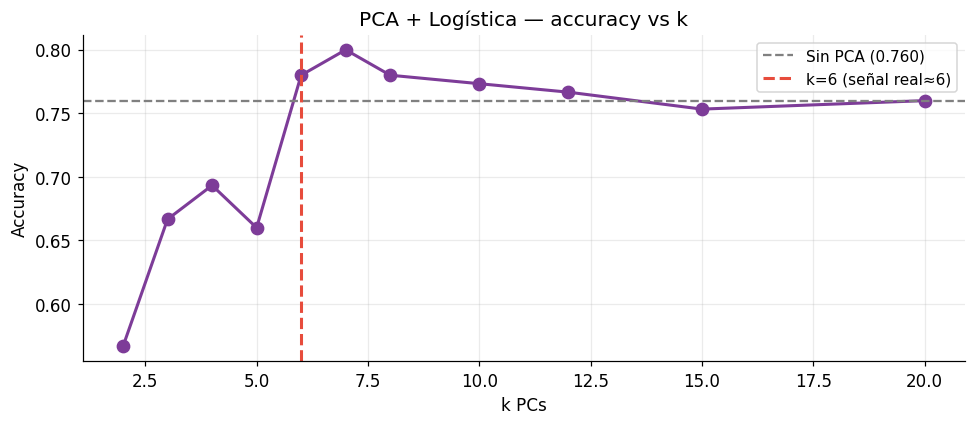

→ Con pocos PCs ya se captura la señal relevante.
→ PCA actúa como regularización: elimina ruido de las últimas dimensiones.


In [8]:
# Visualización: accuracy vs k
ks_pp=[2,3,4,5,6,7,8,10,12,15,20]
accs_pp=[]
for k in ks_pp:
    pipe=Pipeline([('sc',StandardScaler()),('pca',PCA(n_components=k)),
                   ('lr',LogisticRegression(C=1e6,solver='lbfgs',max_iter=500))])
    pipe.fit(Xtr_f,ytr_f)
    accs_pp.append(accuracy_score(yte_f,pipe.predict(Xte_f)))

fig, ax=plt.subplots(figsize=(9, 4))
ax.plot(ks_pp, accs_pp, 'o-', color='#7D3C98', lw=2, markersize=8)
ax.axhline(acc_base, color='gray', lw=1.5, linestyle='--', label=f'Sin PCA ({acc_base:.3f})')
ax.axvline(6, color='#E74C3C', lw=2, linestyle='--', label='k=6 (señal real≈6)')
ax.set(xlabel='k PCs', ylabel='Accuracy', title='PCA + Logística — accuracy vs k')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()
print('→ Con pocos PCs ya se captura la señal relevante.')
print('→ PCA actúa como regularización: elimina ruido de las últimas dimensiones.')

---
## 5. Nombrar las PCs — interpretación de negocio

Cada PC es una combinación lineal de features. Usando los loadings más altos podemos ponerle un nombre.

In [9]:
np.random.seed(SEED)
feats_neg=['ingresos','educacion','deuda','mora_30d','mora_90d',
           'num_productos','antiguedad','saldo_prom']
n_neg=400
# Estructura latente: PC1=capacidad financiera, PC2=riesgo crediticio
Z_neg=np.random.randn(n_neg, 3)
W_neg=np.array([
    [ 2.0, 0.0, 0.1],  # ingresos  → PC1
    [ 1.5, 0.0, 0.2],  # educacion → PC1
    [-0.3, 1.8, 0.1],  # deuda     → PC2
    [-0.1, 2.0,-0.2],  # mora_30d  → PC2
    [-0.1, 2.2,-0.1],  # mora_90d  → PC2
    [ 1.0, 0.0, 1.5],  # productos → PC1 y PC3
    [ 0.8,-0.3, 1.2],  # antiguedad→ PC3
    [ 1.2,-0.5, 0.8],  # saldo_prom→ PC1
])
X_neg=Z_neg @ W_neg.T + np.random.randn(n_neg, 8) * 0.4

pca_neg=PCA(n_components=3); pca_neg.fit(StandardScaler().fit_transform(X_neg))
load_neg=pd.DataFrame(pca_neg.components_.T, index=feats_neg, columns=['PC1','PC2','PC3'])

print('Loadings por PC:')
print(load_neg.round(3).to_string())
print(f'\nVarianza: {pca_neg.explained_variance_ratio_.round(3)}')

print('\n── Interpretación de cada PC ──────────────────')
for pc in ['PC1','PC2','PC3']:
    top=load_neg[pc].abs().nlargest(3)
    signos=['+' if load_neg.loc[f,pc]>0 else '-' for f in top.index]
    feats_str=' · '.join([f'{s}{f}' for s,f in zip(signos,top.index)])
    print(f'  {pc}: {feats_str}')

print('\n  PC1 → "Capacidad financiera" (ingresos, educación, saldo)')
print('  PC2 → "Riesgo crediticio" (deuda, mora)')
print('  PC3 → "Antigüedad y lealtad" (productos, antigüedad)')

Loadings por PC:
                 PC1    PC2    PC3
ingresos       0.344  0.290  0.530
educacion      0.362  0.283  0.473
deuda         -0.286  0.482 -0.176
mora_30d      -0.286  0.491  0.044
mora_90d      -0.281  0.499 -0.021
num_productos  0.363  0.275 -0.490
antiguedad     0.407  0.152 -0.467
saldo_prom     0.459  0.118 -0.064

Varianza: [0.539 0.321 0.108]

── Interpretación de cada PC ──────────────────
  PC1: +saldo_prom · +antiguedad · +num_productos
  PC2: +mora_90d · +mora_30d · +deuda
  PC3: +ingresos · -num_productos · +educacion

  PC1 → "Capacidad financiera" (ingresos, educación, saldo)
  PC2 → "Riesgo crediticio" (deuda, mora)
  PC3 → "Antigüedad y lealtad" (productos, antigüedad)


---
## Conclusiones

<div style="background:#F5EEF8;border-left:5px solid #7D3C98;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · No hay una regla única — combinar los tres criterios**
Empezar con 80% de varianza, verificar con Kaiser, confirmar con el codo. Si los tres coinciden → alta confianza en k.

**02 · Los loadings dan interpretabilidad**
Una PC con loadings altos en mora_30d y mora_90d es claramente un componente de riesgo crediticio.

**03 · PCA como preprocesamiento regulariza**
Eliminar las últimas PCs equivale a filtrar ruido. Puede mejorar modelos supervisados en datasets de alta dimensión.

</div>

---
<div style="background:#512E5F;color:white;padding:28px 24px;border-radius:8px;">

<strong>🎓 Curso 8 — Modelos Estadísticos — Completado</strong>

<p style="margin:12px 0 0 0;">Módulo 1: Regresión Lineal &nbsp;·&nbsp; Módulo 2: Regresión Logística &nbsp;·&nbsp; Módulo 3: Análisis Discriminante &nbsp;·&nbsp; Módulo 4: PCA</p>
<p style="margin:8px 0 0 0;opacity:0.8;">Docente: Josef Rodriguez</p>

</div>